<a href="https://colab.research.google.com/github/RenteriaRaul/Doctorado-DCAG/blob/main/notebooks/02_exceedance_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio actual: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación
Excedencia calculada


,CLAVE,NOMBRE,ESTADO,LATITUD,LONGITUD,EXCEDENCIA_50MM,total_dias,dias_excedencia
0,6001,ARMERIA,COLIMA,18.938333,-103.946389,0.010219,26225,268
1,6002,BUENAVISTA,COLIMA,19.261944,-103.613333,0.009513,30381,289
2,6003,CALLEJONES,COLIMA,18.815556,-103.634167,0.009432,27354,258
3,6004,CAMOTLAN DE MIRAFLORES,COLIMA,19.225000,-104.232222,0.010597,21515,228
4,6005,CERRO DE ORTEGA,COLIMA,18.758889,-103.725833,0.011054,22436,248


/usr/local/lib/python3.12/dist-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


GeoTIFF generado: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/excedencia_colima.tif


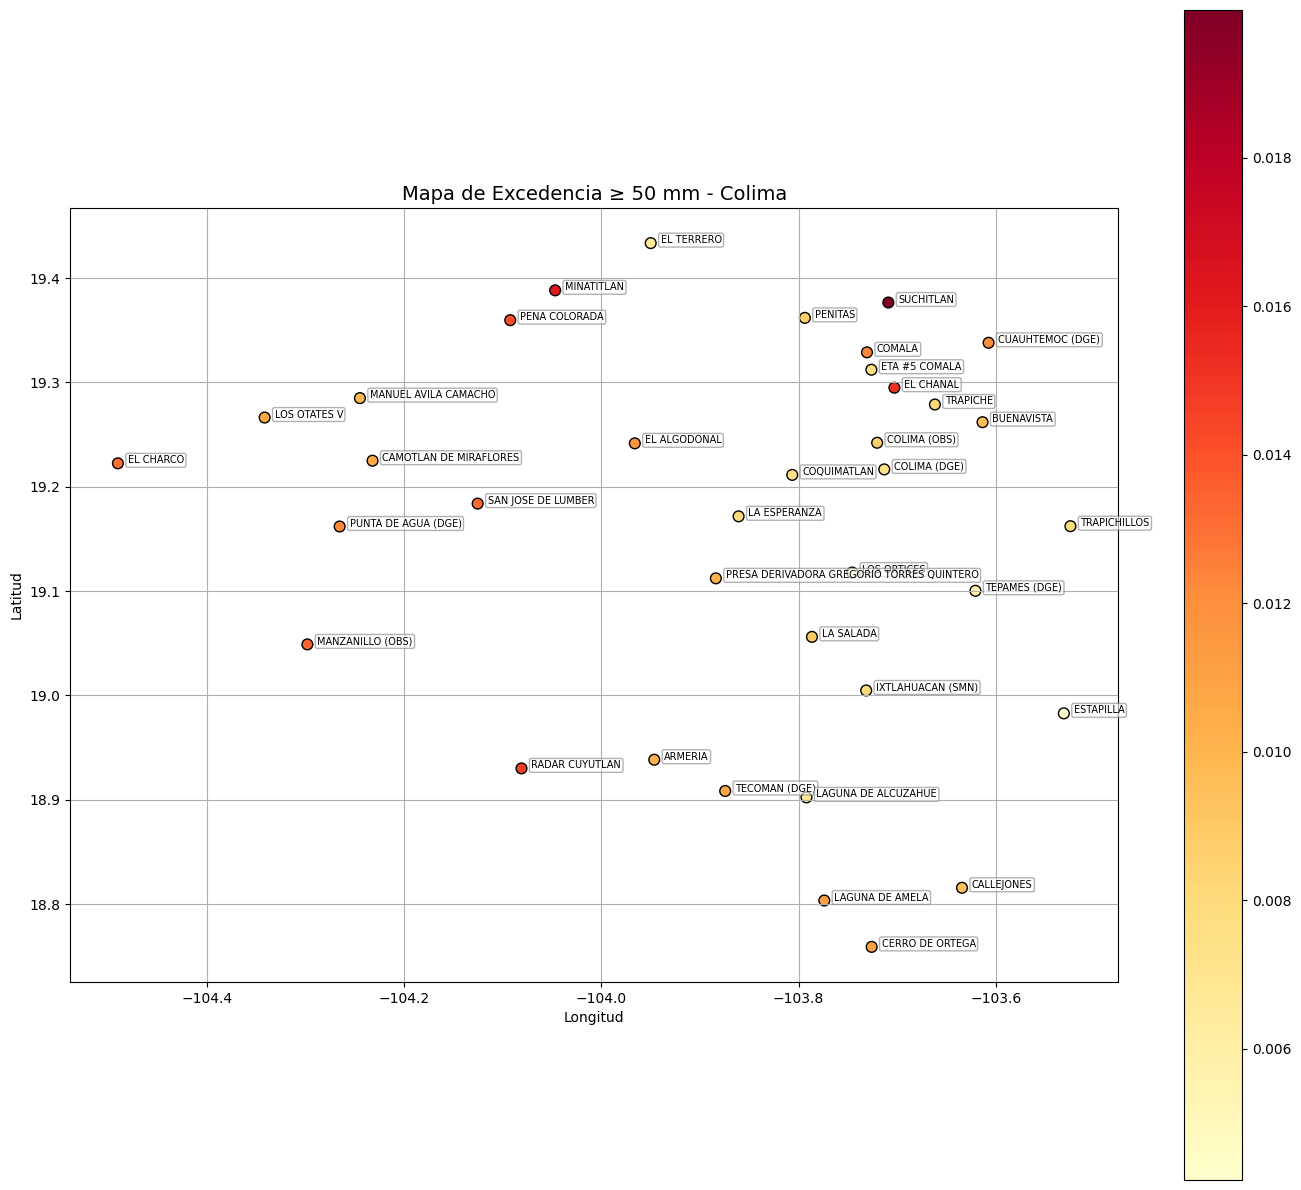

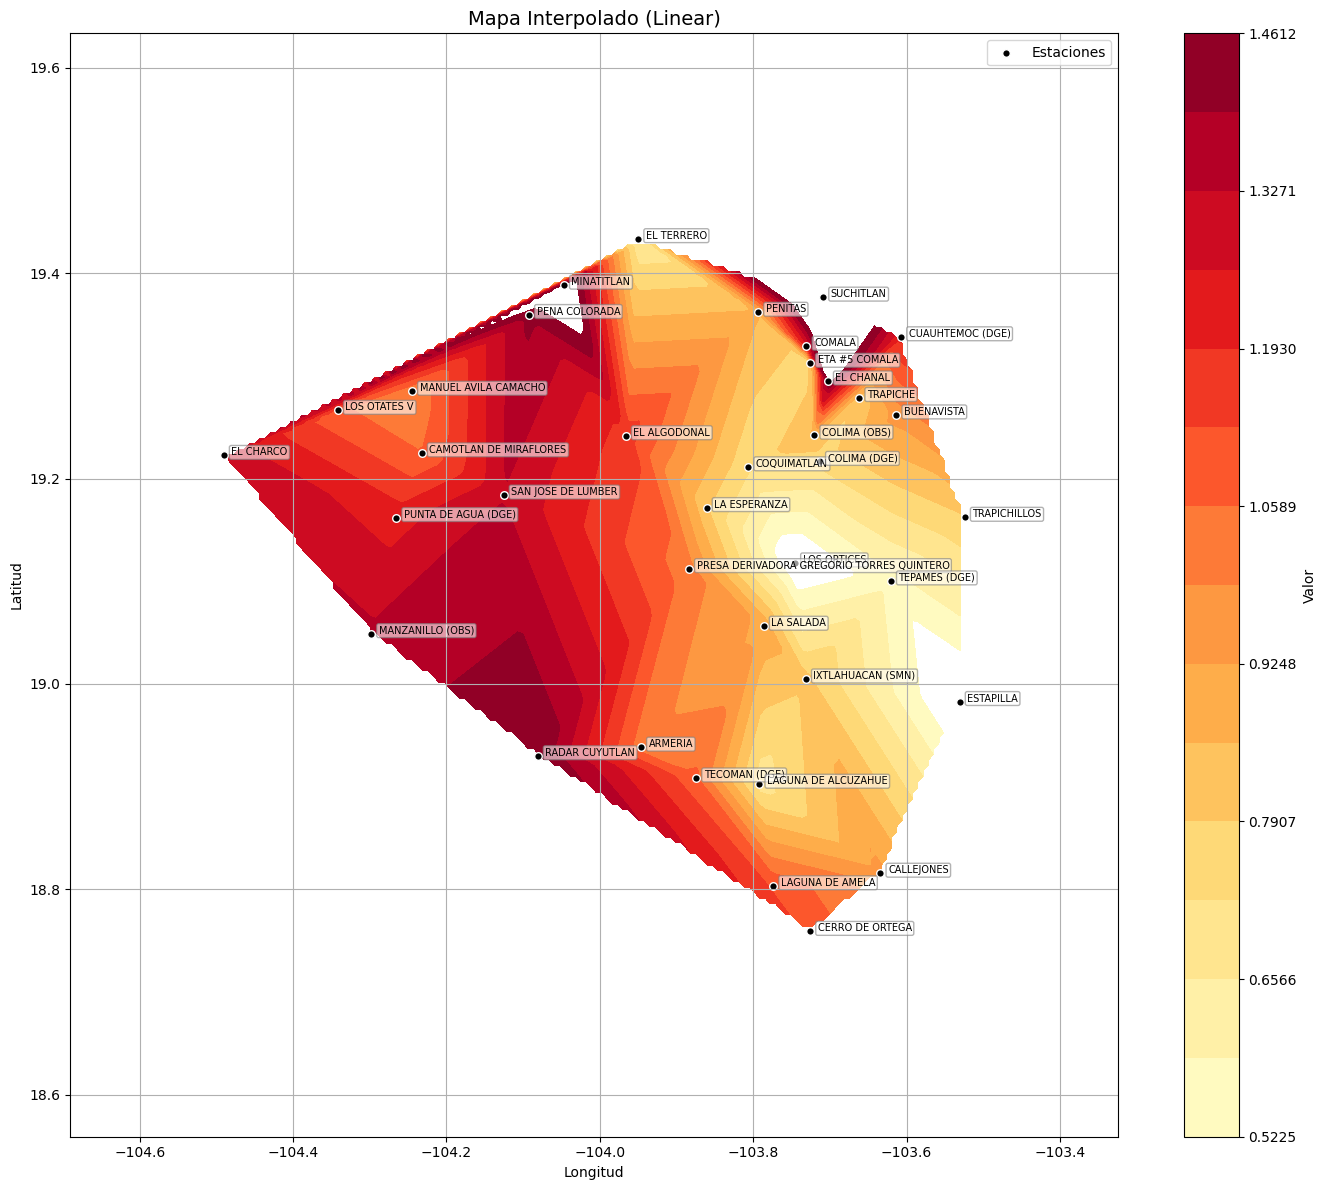

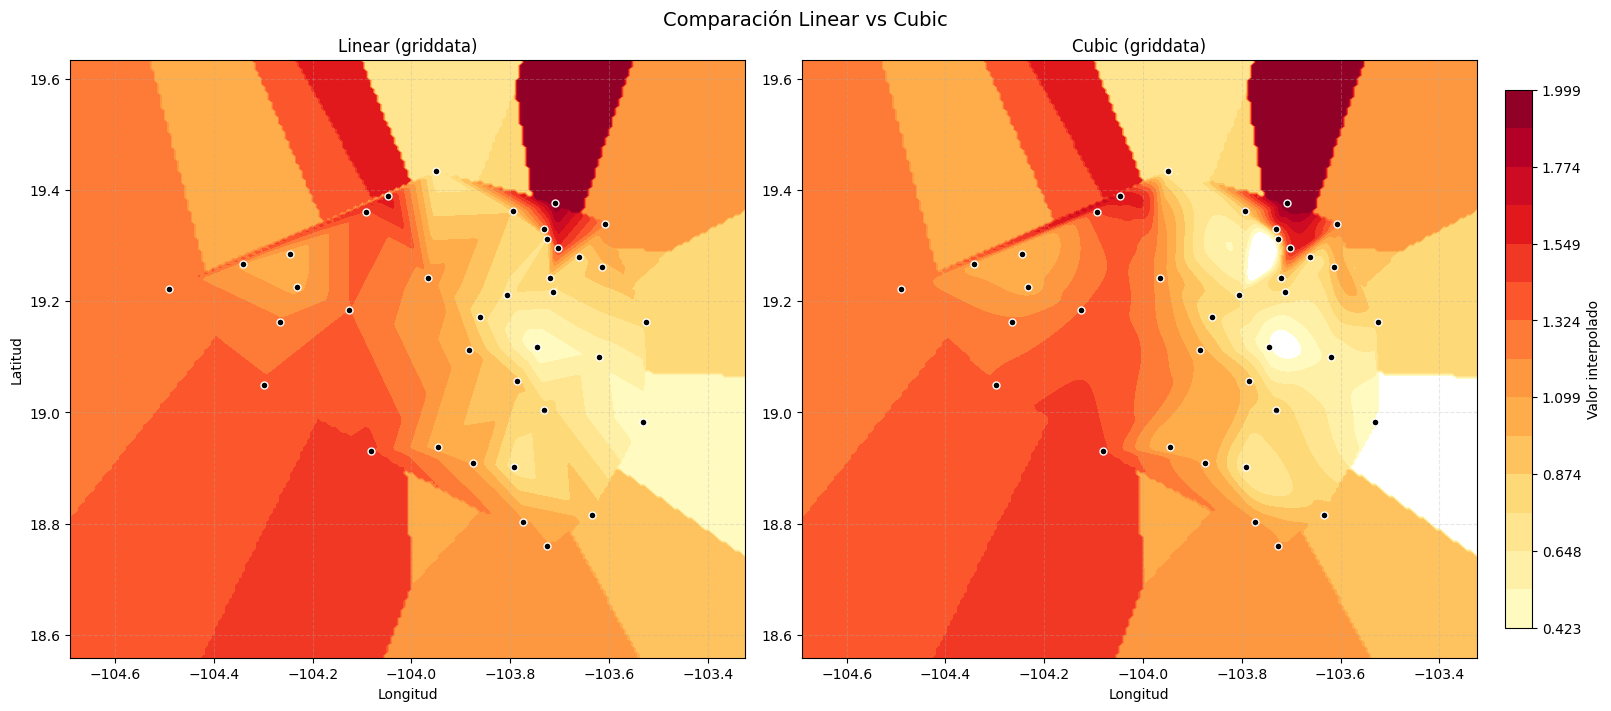

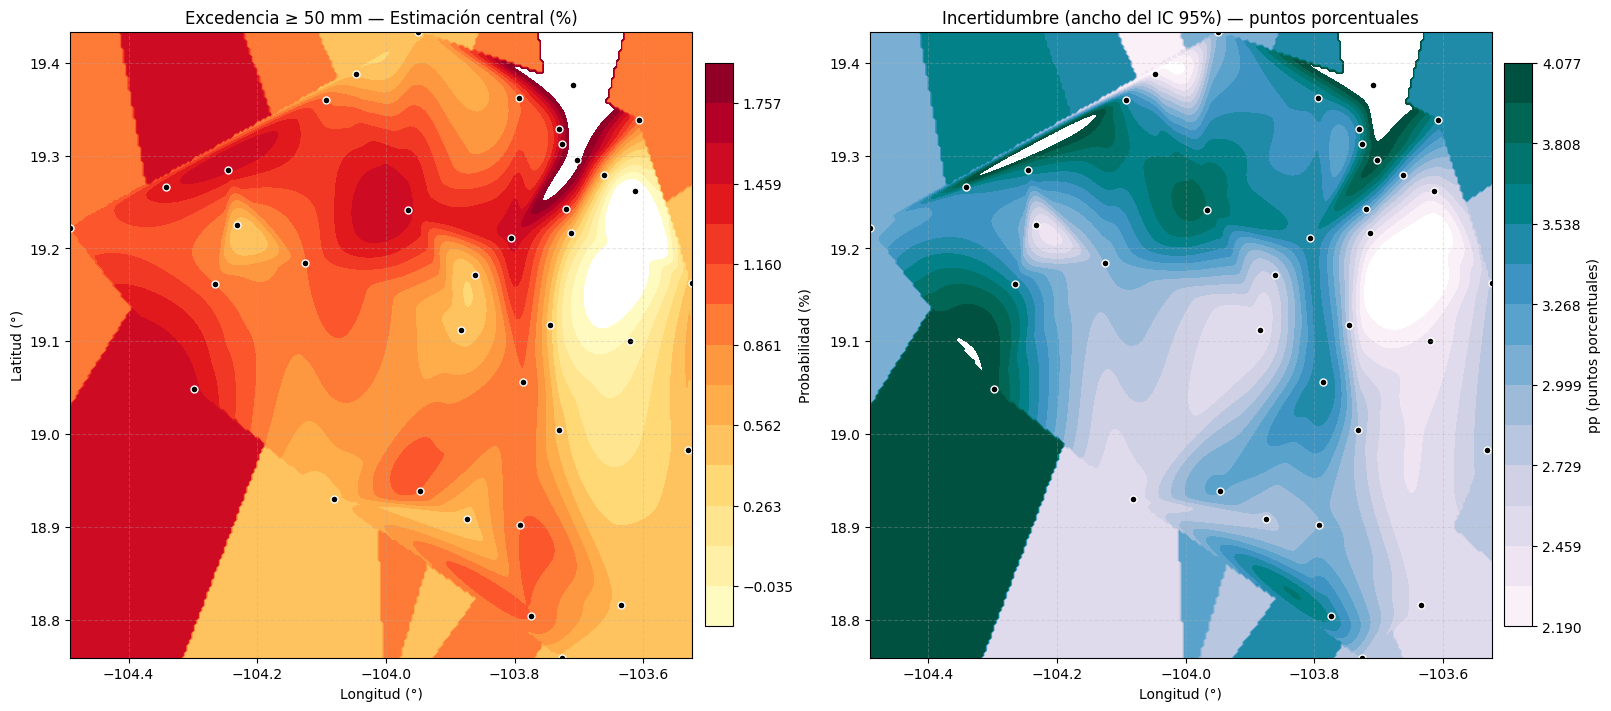

In [6]:
# ============================================================
# NOTEBOOK LIMPIO - EXCEDENCIAS (PIPELINE COMPLETO)
# ============================================================

from google.colab import drive
import os
import sys
import numpy as np
import pandas as pd

# =============================
# 1. CONFIGURACIÓN
# =============================
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
os.chdir(PROJECT_DIR)

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print("Directorio actual:", os.getcwd())

# =============================
# 2. IMPORTAR MÓDULOS
# =============================
from scripts.exceedance import procesar_excedencia_batch_excel, preparar_excedencia_para_interpolacion
from scripts.interpolation import crear_malla_interpolacion, interpolar_superficie, comparar_interpolaciones, plot_superficie_interpolada
from scripts.uncertainty import calcular_ic_excedencia_estaciones, interpolar_superficies_incertidumbre, plot_incertidumbre_excedencia
from scripts.raster_export import exportar_desde_puntos_a_geotiff
from scripts.mapping import crear_geodataframe_estaciones, plot_mapa_estetico_avanzado

# =============================
# 3. RUTAS
# =============================
CARPETA_ESTACIONES = os.path.join(PROJECT_DIR, "estaciones_conagua_excel/Colima")
ARCHIVO_COORDS = os.path.join(PROJECT_DIR, "estaciones_conagua_excel/Colima/CoordenadasEstacionesColima.xlsx")

OUT_EXCEDENCIA = os.path.join(PROJECT_DIR, "excedencia_colima.csv")
OUT_TIFF = os.path.join(PROJECT_DIR, "excedencia_colima.tif")

# =============================
# 4. CALCULAR EXCEDENCIA (BATCH)
# =============================
df_excedencia, log_df = procesar_excedencia_batch_excel(
    carpeta_estaciones=CARPETA_ESTACIONES,
    archivo_coordenadas=ARCHIVO_COORDS,
    export_csv_path=OUT_EXCEDENCIA
)

print("Excedencia calculada")
display(df_excedencia.head())

# =============================
# 5. MAPA DE ESTACIONES
# =============================
gdf = crear_geodataframe_estaciones(df_excedencia)

fig, ax = plot_mapa_estetico_avanzado(
    gdf,
    col_val="EXCEDENCIA_50MM",
    col_label="NOMBRE",
    title="Mapa de Excedencia ≥ 50 mm - Colima"
)

# =============================
# 6. PREPARAR DATOS PARA INTERPOLACIÓN
# =============================
df_clean, points, values = preparar_excedencia_para_interpolacion(
    df_excedencia,
    convertir_a_porcentaje=True
)

# =============================
# 7. CREAR MALLA
# =============================
GX, GY, extent = crear_malla_interpolacion(
    df_clean,
    nx=200,
    ny=200,
    margin=0.2
)

# =============================
# 8. INTERPOLACIÓN (LINEAL)
# =============================
Z_linear = interpolar_superficie(points, values, GX, GY, method="linear")

plot_superficie_interpolada(
    df_clean,
    GX,
    GY,
    Z_linear,
    title="Mapa Interpolado (Linear)"
)

# =============================
# 9. COMPARACIÓN LINEAR vs CUBIC
# =============================
fig, axes, res = comparar_interpolaciones(
    df_clean,
    points,
    values,
    GX,
    GY,
    fill_outside=True,
    title="Comparación Linear vs Cubic"
)

# =============================
# 10. INCERTIDUMBRE
# =============================
df_ic = calcular_ic_excedencia_estaciones(df_excedencia)

interp_unc = interpolar_superficies_incertidumbre(df_ic)

fig, axes = plot_incertidumbre_excedencia(
    df_ic,
    interp_unc["GX"],
    interp_unc["GY"],
    interp_unc["Z_mean"],
    interp_unc["Z_width"]
)

# =============================
# 11. EXPORTAR A QGIS (GeoTIFF)
# =============================
res_tif = exportar_desde_puntos_a_geotiff(
    df_clean,
    out_tif=OUT_TIFF,
    col_val="EXCEDENCIA_50MM",
    method="linear"
)

print("GeoTIFF generado:", res_tif["out_tif"])

# ============================================================
# FIN
# ============================================================

In [5]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Doctorado /Probabilidad/Precipitación"
SCRIPTS_DIR = os.path.join(PROJECT_DIR, "scripts")

os.makedirs(SCRIPTS_DIR, exist_ok=True)

files_to_create = [
    "__init__.py",
    "bootstrap_utils.py",
    "station_analysis.py",
    "batch_return_levels.py",
    "exceedance.py",
    "interpolation.py",
    "uncertainty.py",
    "raster_export.py",
    "mapping.py",
]

for fname in files_to_create:
    fpath = os.path.join(SCRIPTS_DIR, fname)
    if not os.path.exists(fpath):
        with open(fpath, "w", encoding="utf-8") as f:
            f.write("")

print("Carpeta scripts lista en:", SCRIPTS_DIR)
print("Archivos creados:")
for fname in files_to_create:
    print("-", fname)

Carpeta scripts lista en: /content/drive/MyDrive/Doctorado /Probabilidad/Precipitación/scripts
Archivos creados:
- __init__.py
- bootstrap_utils.py
- station_analysis.py
- batch_return_levels.py
- exceedance.py
- interpolation.py
- uncertainty.py
- raster_export.py
- mapping.py
